In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
x, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

In [3]:
df = pd.DataFrame(x, columns=["Feature_1", "Feature_2"])

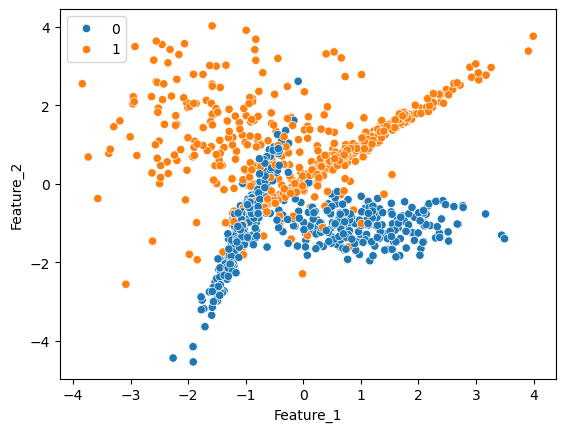

In [4]:
sns.scatterplot(
    x=df["Feature_1"],
    y=df["Feature_2"],
    hue=y
)

plt.show()

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=10
)

In [6]:
model = SVC(kernel="rbf")

In [7]:
model.fit(x_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
y_pred = model.predict(x_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [10]:
print(confusion_matrix(y_test, y_pred))

[[115   7]
 [ 18 110]]


In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       122
           1       0.94      0.86      0.90       128

    accuracy                           0.90       250
   macro avg       0.90      0.90      0.90       250
weighted avg       0.90      0.90      0.90       250



In [12]:
param_grid = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": [1, 0.1, 0.01, 0.001, 0.0001],
    "kernel": ["rbf"]
}

In [13]:
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    verbose=3
)

In [14]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.913 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.813 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.873 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.893 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.887 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.853 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.813 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.867 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [15]:
print(grid.best_params_)

{'C': 1000, 'gamma': 1, 'kernel': 'rbf'}


In [16]:
grid_pred = grid.predict(x_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, grid_pred))

print(confusion_matrix(y_test, grid_pred))

print(classification_report(y_test, grid_pred))

Accuracy: 0.912
[[119   3]
 [ 19 109]]
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       122
           1       0.97      0.85      0.91       128

    accuracy                           0.91       250
   macro avg       0.92      0.91      0.91       250
weighted avg       0.92      0.91      0.91       250



In [18]:
kernels = ["linear", "poly", "rbf", "sigmoid"]

for k in kernels:
    model = SVC(kernel=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    print("Kernel:", k)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("-" * 40)

Kernel: linear
Accuracy: 0.876
----------------------------------------
Kernel: poly
Accuracy: 0.852
----------------------------------------
Kernel: rbf
Accuracy: 0.9
----------------------------------------
Kernel: sigmoid
Accuracy: 0.752
----------------------------------------
